# Notebook 4 - Decision Tree & Random Forest

This notebook develops and evaluates Decision Tree and Random Forest regression models for predicting residential property close prices.

The models use chronological, leakage-aware training, validation, and testing datasets. Decision Tree and Random Forest hyperparameters are selected on the validation month. After all choices are frozen, each model is refitted on training plus validation data and evaluated once on the untouched testing month using R², MAE, MAPE, MdAPE, and RMSE.

## Week 5 Summary

- Trained a Decision Tree Regressor to capture nonlinear relationships in property data.
- Evaluated several maximum tree depths and selected the best-performing depth while keeping the remaining hyperparameters fixed.
- Trained a Random Forest Regressor using multiple decision trees to improve predictive stability and reduce model variance.
- Evaluated both models using R², MAE, MAPE, MdAPE, and RMSE.
- Compared model performance against the Linear Regression baseline.
- Visualized the Decision Tree structure and examined model feature importance.
- Considered both predictive accuracy and computational efficiency when selecting model parameters.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path
# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "validation_encoded": data_dir / f"validation_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
validation_encoded_df = dfs["validation_encoded"]
test_encoded_df = dfs["test_encoded"]

# Read the retained transaction periods for an exact split summary
period_source = pd.read_csv(
    data_dir / f"cleaned_crmls_{TRAIN_MONTHS}m.csv",
    usecols = ["ClosePeriod"]
)
available_periods = pd.PeriodIndex(
    period_source["ClosePeriod"].dropna().astype(str),
    freq = "M"
).unique().sort_values()
test_period = available_periods.max()
validation_period = test_period - 1
training_periods = available_periods[available_periods < validation_period]

print(
    f"Training: {training_periods.min()} to {training_periods.max()} "
    f"({len(training_periods)} months)"
)
print(f"Validation: {validation_period} (1 month)")
print(f"Test: {test_period} (1 month)")

Training: 2023-11 to 2026-04 (30 months)
Validation: 2026-05 (1 month)
Test: 2026-06 (1 month)


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Validation Set shape:", validation_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317401, 128)
Validation Set shape: (11646, 128)
Test Set shape: (12443, 128)


## Prepare Features and Target

In [5]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Validation set - used only for model/hyperparameter selection
x_validation = validation_encoded_df.drop(columns = ["ClosePrice"])
y_validation = validation_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]
# Final training data used only after all choices are frozen
x_train_final = pd.concat([x_train, x_validation], ignore_index = True)
y_train_final = pd.concat([y_train, y_validation], ignore_index = True)

In [6]:
print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(317401, 127)
(11646, 127)
(12443, 127)


## Model-Selection Training Target Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]
def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"
target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"317,401"
mean,"$1,189,779.56"
std,"$945,850.98"
min,"$189,000.00"
25%,"$620,000.00"
50%,"$887,000.00"
75%,"$1,415,000.00"
max,"$8,200,000.00"


## Train Decision Tree Model

### Test different depth of Tree

To identify an appropriate level of model complexity, multiple maximum tree depths are evaluated while keeping the remaining hyperparameters fixed. The configuration with the highest validation R² is selected.

The testing month is not used during this selection. After the depth is frozen, the model is refitted on the combined training and validation data and evaluated once on the testing month.

In [8]:
# Find the best depth of Tree
depth_results = []
for depth in [3, 5, 8, 10, 12, 15, 20]:
    model = DecisionTreeRegressor(
        max_depth = depth, 
        min_samples_split = 10,
        min_samples_leaf = 5,
        random_state = 42
    )
    model.fit(x_train, y_train)
    y_pred_depth = model.predict(x_validation)
    depth_results.append({
        "Max Depth": depth,
        "R²": r2_score(y_validation, y_pred_depth),
        "MAE": mean_absolute_error(y_validation, y_pred_depth)
    })
depth_results_df = pd.DataFrame(depth_results)
depth_results_df.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}"
}).hide(axis = "index")

Max Depth,R²,MAE
3,0.4267,"$498,635.07"
5,0.5369,"$417,577.80"
8,0.6567,"$337,144.75"
10,0.7208,"$296,059.04"
12,0.7619,"$263,226.93"
15,0.7973,"$228,859.42"
20,0.8074,"$214,176.55"


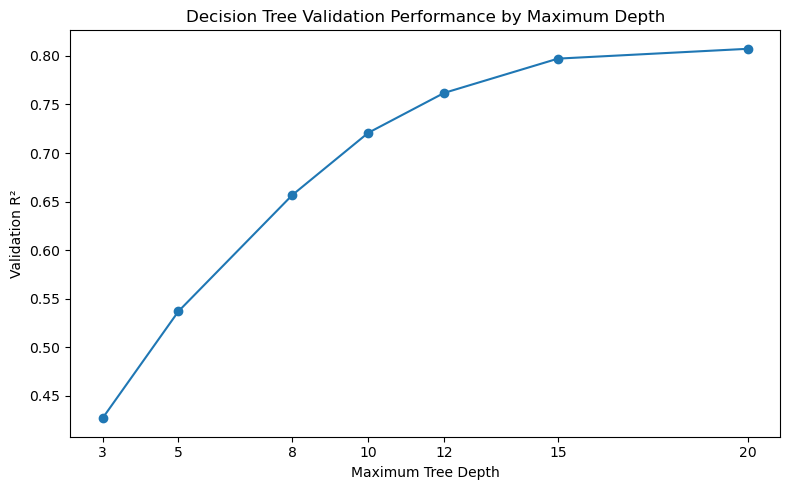

In [9]:
plt.figure(figsize = (8, 5))
plt.plot(depth_results_df["Max Depth"], depth_results_df["R²"], marker = "o")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Validation R²")
plt.title("Decision Tree Validation Performance by Maximum Depth")
plt.xticks(depth_results_df["Max Depth"])
plt.tight_layout()
plt.show()

Decision Tree performance generally improved as the maximum depth increased, although the gains became smaller at greater depths. The configuration with the highest validation R² was selected for the final model.

In [10]:
best_depth = int(depth_results_df.loc[depth_results_df["R²"].idxmax(), "Max Depth"])
print(f"Best max depth based on validation R²: {best_depth}")

Best max depth based on validation R²: 20


### Rerun the Decision Tree model

In [11]:
# Refit the selected Decision Tree on train + validation
dt_regressor = DecisionTreeRegressor(
    max_depth = best_depth, 
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)
dt_regressor.fit(x_train_final, y_train_final)
print("Decision Tree training completed.")

Decision Tree training completed.


## Generate Predictions

In [12]:
y_pred_dt = dt_regressor.predict(x_test)

## Decision Tree Visualization

The first three levels of the trained Decision Tree are visualized below.  
Only the upper levels are displayed to preserve readability because the complete tree contains a large number of nodes and branches.

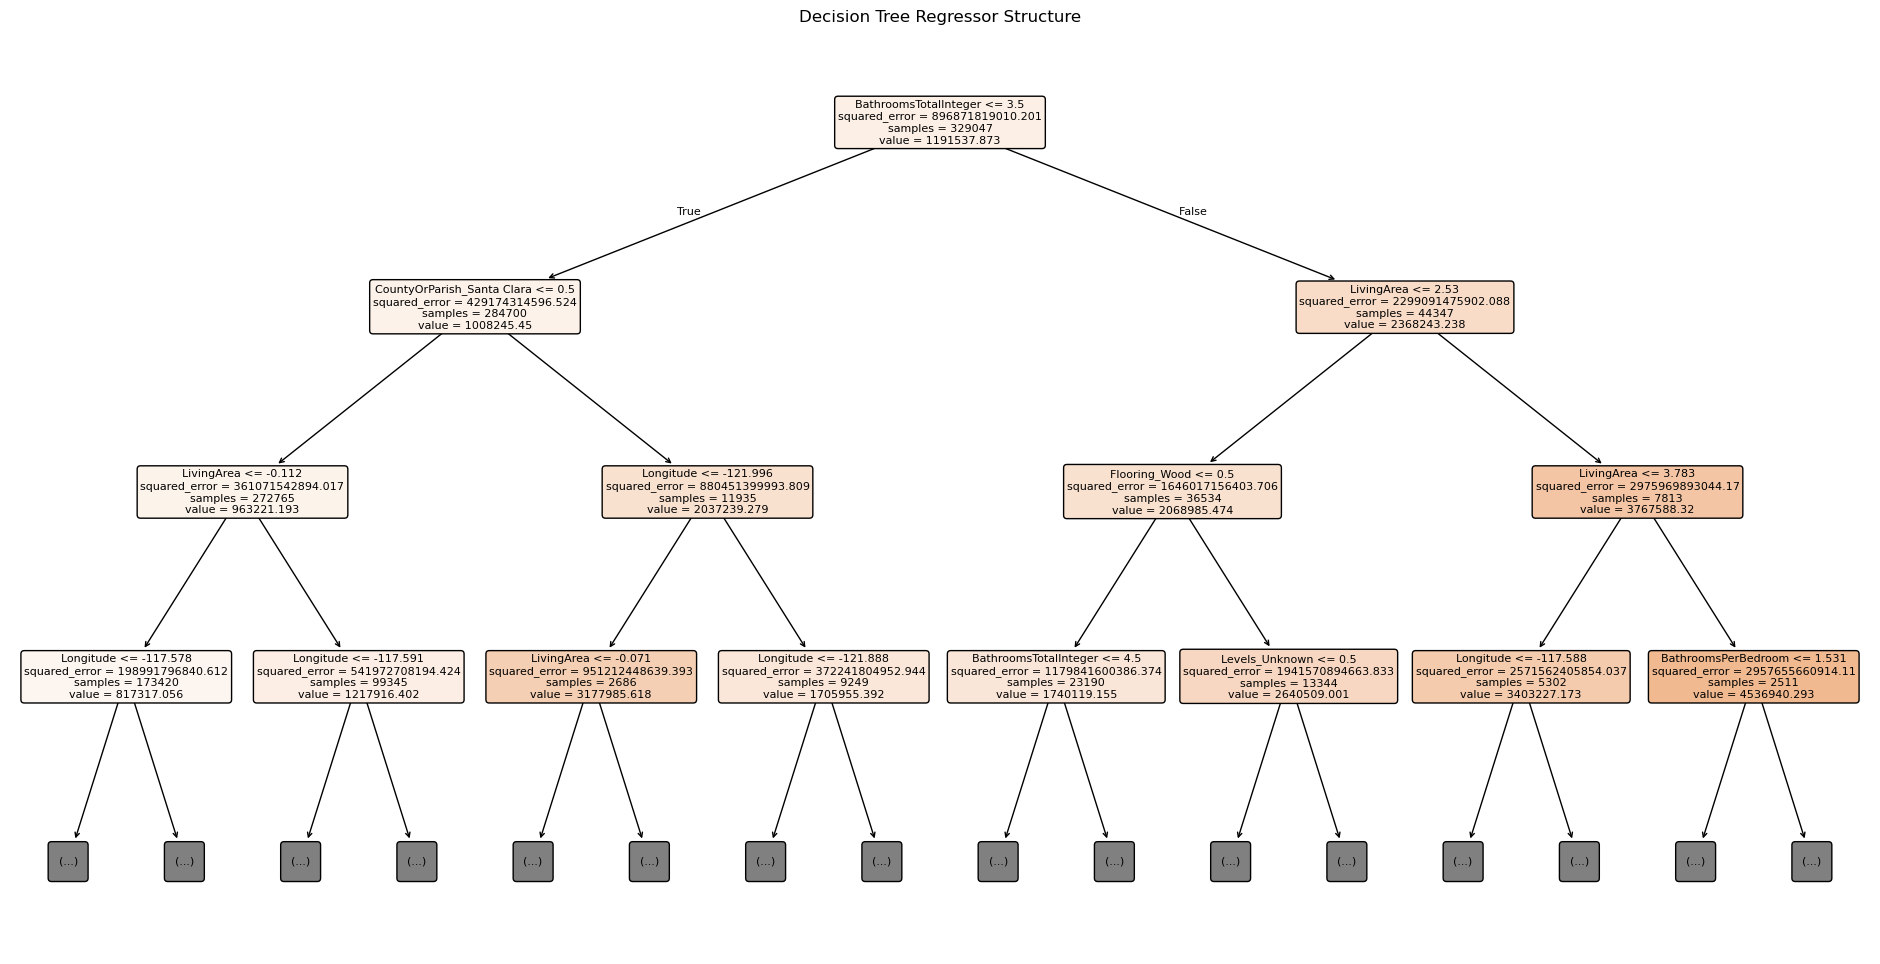

In [13]:
plt.figure(figsize = (24, 12))
plot_tree(dt_regressor, feature_names = x_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 8)
plt.title("Decision Tree Regressor Structure")
plt.show()

## Decision Tree Feature Importance

The feature importance scores below indicate the relative contribution of each feature to the Decision Tree's predictions. Higher importance values represent features that contribute more frequently to reducing prediction error during tree construction.

In [14]:
dt_feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": dt_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
dt_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.264709
5,Longitude,0.173819
4,Latitude,0.156515
6,LivingArea,0.154535
86,CountyOrParish_Santa Clara,0.048931
121,Flooring_Wood,0.042038
24,LivingAreaPerBedroom,0.014165
76,CountyOrParish_Riverside,0.012232
84,CountyOrParish_San Mateo,0.012083
126,Levels_Unknown,0.010456


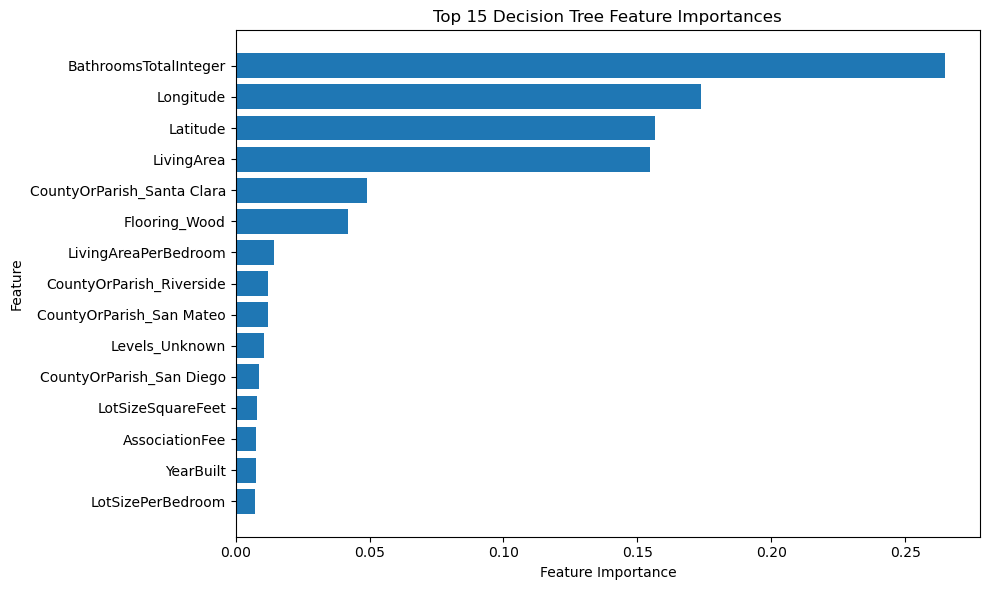

In [15]:
plt.figure(figsize = (10, 6))
plt.barh(dt_feature_importance["Feature"][::-1], dt_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## Train Random Forest Model

Random Forest candidate configurations are trained on the training period and compared on the validation month. The testing month is not used for hyperparameter selection.

Model selection uses a predefined near-best rule rather than automatically choosing the numerically highest R². A candidate is considered near-best when its validation R² is within 0.002 of the best R² and its validation MdAPE is within 0.10 percentage point of the best MdAPE. Among candidates meeting both conditions, the shallowest tree is selected; if no candidate satisfies both tolerances, the model with the lowest validation MdAPE is used. After selection, the final model is refitted on the combined training and validation data.

In [16]:
rf_candidates = [
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 5},
    {"max_depth": 20, "min_samples_leaf": 5},
    {"max_depth": 25, "min_samples_leaf": 5},
    {"max_depth": 30, "min_samples_leaf": 5},
]
rf_validation_results = []
R2_TOLERANCE = 0.002
MDAPE_TOLERANCE = 0.10

for params in rf_candidates:
    candidate_model = RandomForestRegressor(
        n_estimators = 50,
        max_depth = params["max_depth"],
        min_samples_split = 10,
        min_samples_leaf = params["min_samples_leaf"],
        n_jobs = -1,
        random_state = 42
    )
    candidate_model.fit(x_train, y_train)
    validation_predictions = candidate_model.predict(x_validation)
    validation_mdape = np.median(
        np.abs((y_validation - validation_predictions) / y_validation)
    ) * 100
    rf_validation_results.append({
        **params,
        "R²": r2_score(y_validation, validation_predictions),
        "MAE": mean_absolute_error(y_validation, validation_predictions),
        "MdAPE (%)": validation_mdape
    })

rf_validation_results_df = pd.DataFrame(rf_validation_results)
best_validation_r2 = rf_validation_results_df["R²"].max()
best_validation_mdape = rf_validation_results_df["MdAPE (%)"].min()

rf_validation_results_df["Near Best"] = (
    (rf_validation_results_df["R²"] >= best_validation_r2 - R2_TOLERANCE)
    &
    (rf_validation_results_df["MdAPE (%)"] <= best_validation_mdape + MDAPE_TOLERANCE)
)

near_best_models = rf_validation_results_df[
    rf_validation_results_df["Near Best"]
].copy()

if near_best_models.empty:
    selected_rf_row = rf_validation_results_df.loc[
        rf_validation_results_df["MdAPE (%)"].idxmin()
    ]
    selection_reason = "No model met both tolerances; selected lowest validation MdAPE."
else:
    selected_rf_row = near_best_models.sort_values(
        by = ["max_depth", "min_samples_leaf"],
        ascending = [True, False]
    ).iloc[0]
    selection_reason = "Selected the shallowest model within the R² and MdAPE tolerances."

best_rf_params = selected_rf_row[
    ["max_depth", "min_samples_leaf"]
].to_dict()
best_rf_params = {key: int(value) for key, value in best_rf_params.items()}

display(
    rf_validation_results_df.style.format({
        "R²": "{:.4f}",
        "MAE": "${:,.2f}",
        "MdAPE (%)": "{:.4f}%"
    }).hide(axis = "index")
)
print(f"R² tolerance: {R2_TOLERANCE:.4f}")
print(f"MdAPE tolerance: {MDAPE_TOLERANCE:.2f} percentage point")
print(selection_reason)
print("Selected Random Forest parameters:", best_rf_params)

# Refit the selected Random Forest on train + validation
rf_regressor = RandomForestRegressor(
    n_estimators = 50,
    max_depth = best_rf_params["max_depth"],
    min_samples_split = 10,
    min_samples_leaf = best_rf_params["min_samples_leaf"],
    n_jobs = -1,
    random_state = 42
)
rf_regressor.fit(x_train_final, y_train_final)
print("Final Random Forest training completed.")

max_depth,min_samples_leaf,R²,MAE,MdAPE (%),Near Best
10,5,0.7775,"$263,516.19",15.2505%,False
15,5,0.8577,"$194,595.62",10.1900%,False
20,5,0.8733,"$175,285.44",8.4250%,False
25,5,0.8752,"$171,701.51",8.0482%,True
30,5,0.8755,"$171,206.84",8.0130%,True


R² tolerance: 0.0020
MdAPE tolerance: 0.10 percentage point
Selected the shallowest model within the R² and MdAPE tolerances.
Selected Random Forest parameters: {'max_depth': 25, 'min_samples_leaf': 5}
Final Random Forest training completed.


Final Random Forest training completed.


## Generate Predictions

In [17]:
y_pred_rf = rf_regressor.predict(x_test)

## Random Forest Feature Importance

In [18]:
rf_feature_importance = pd.DataFrame({"Feature": x_train_final.columns, "Importance": rf_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
rf_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.260308
5,Longitude,0.173885
6,LivingArea,0.156952
4,Latitude,0.154241
86,CountyOrParish_Santa Clara,0.048270
121,Flooring_Wood,0.039968
24,LivingAreaPerBedroom,0.016521
84,CountyOrParish_San Mateo,0.012204
76,CountyOrParish_Riverside,0.009115
18,AssociationFee,0.008647


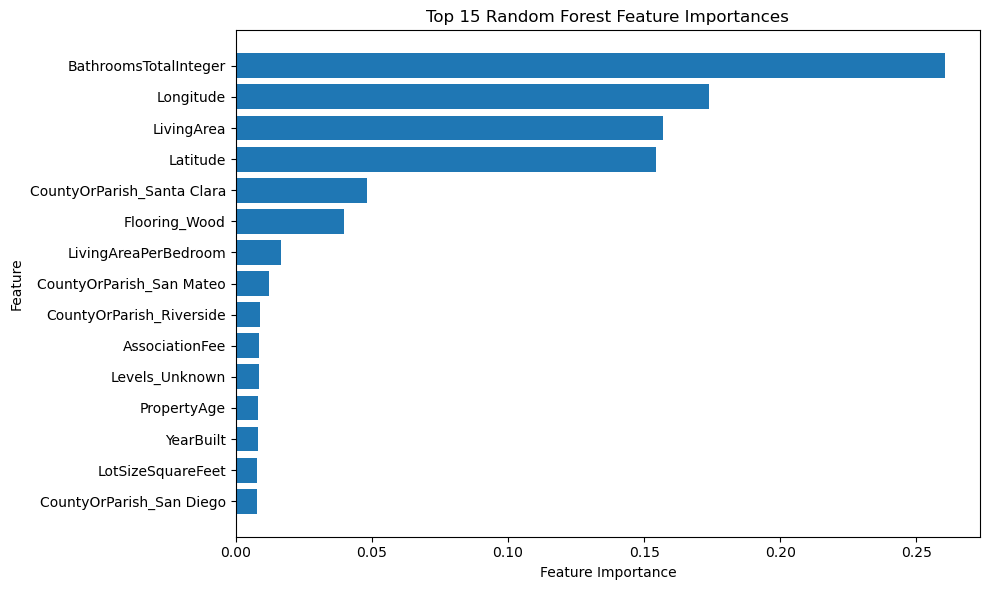

In [19]:
plt.figure(figsize = (10, 6))
plt.barh(rf_feature_importance["Feature"][::-1], rf_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Evaluate Model Performance

In [20]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [21]:
r2_dt, mae_dt, mape_dt, mdape_dt, rmse_dt = evaluation(y_test, y_pred_dt)

In [22]:
r2_rf, mae_rf, mape_rf, mdape_rf, rmse_rf = evaluation(y_test, y_pred_rf)

## Regenerate Linear Regression Results

In [23]:
lr_regressor = LinearRegression()
lr_regressor.fit(x_train_final, y_train_final)
y_pred_lr = lr_regressor.predict(x_test)
r2_lr, mae_lr, mape_lr, mdape_lr, rmse_lr = evaluation(y_test, y_pred_lr)

## Current Model Results

In [24]:
# Organize Results to dataframe
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"],
    "R²": [r2_lr, r2_dt, r2_rf],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "MAPE (%)": [mape_lr, mape_dt, mape_rf],
    "MdAPE (%)": [mdape_lr, mdape_dt, mdape_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})
# Convert to Dataframe
results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6410,"$358,844.63",33.0237%,24.9839%,"$588,238.00"
Decision Tree Regressor,0.8131,"$210,221.47",15.5580%,10.1449%,"$424,456.10"
Random Forest Regressor,0.8749,"$168,931.31",12.4763%,7.9706%,"$347,200.70"


## Normalized Model Performance Comparison

Because the evaluation metrics use different units and scales, they cannot be compared directly on a single axis. Each metric is therefore converted into a relative performance score, where 1.0 represents the best-performing model for that metric and higher values indicate stronger performance. These normalized scores indicate relative ranking only and should not be interpreted as absolute model performance.

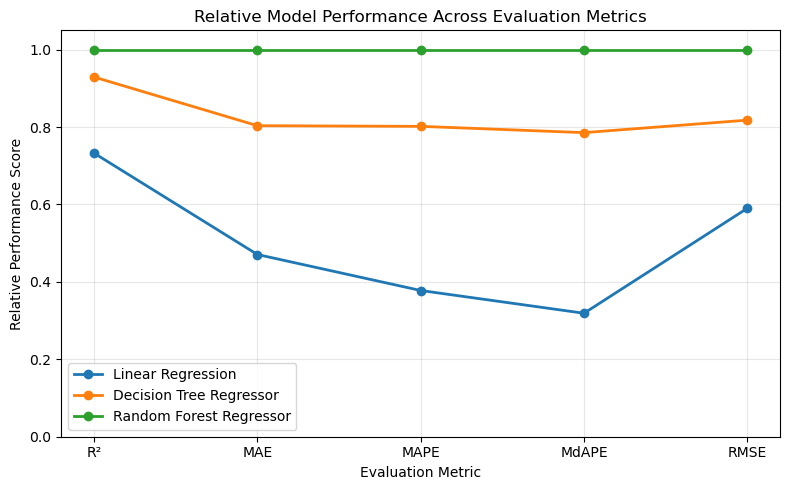

In [25]:
comparison_scores = pd.DataFrame({
    "Model": results["Model"],
    "R²": results["R²"] / results["R²"].max(),
    "MAE": results["MAE"].min() / results["MAE"],
    "MAPE": results["MAPE (%)"].min() / results["MAPE (%)"],
    "MdAPE": results["MdAPE (%)"].min() / results["MdAPE (%)"],
    "RMSE": results["RMSE"].min() / results["RMSE"]
}).set_index("Model")
plt.figure(figsize = (8, 5))
for model in comparison_scores.index:
    plt.plot(comparison_scores.columns, comparison_scores.loc[model], marker = "o", linewidth = 2, label = model)
plt.ylim(0, 1.05)
plt.ylabel("Relative Performance Score")
plt.xlabel("Evaluation Metric")
plt.title("Relative Model Performance Across Evaluation Metrics")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Actual vs Predicted Plot

### Decision Tree

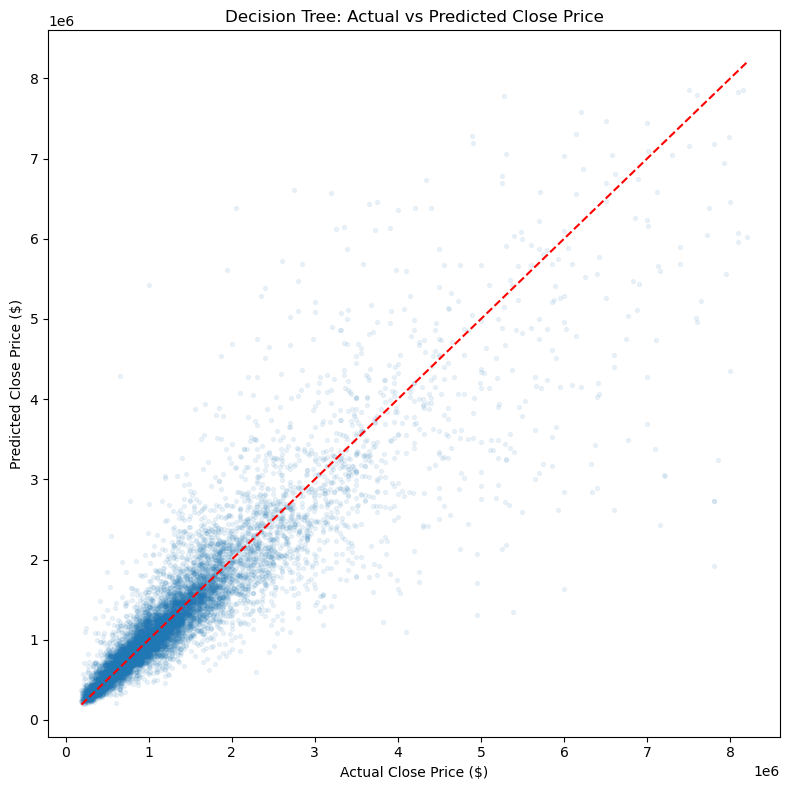

In [26]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_dt, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Decision Tree: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

### Random Forest

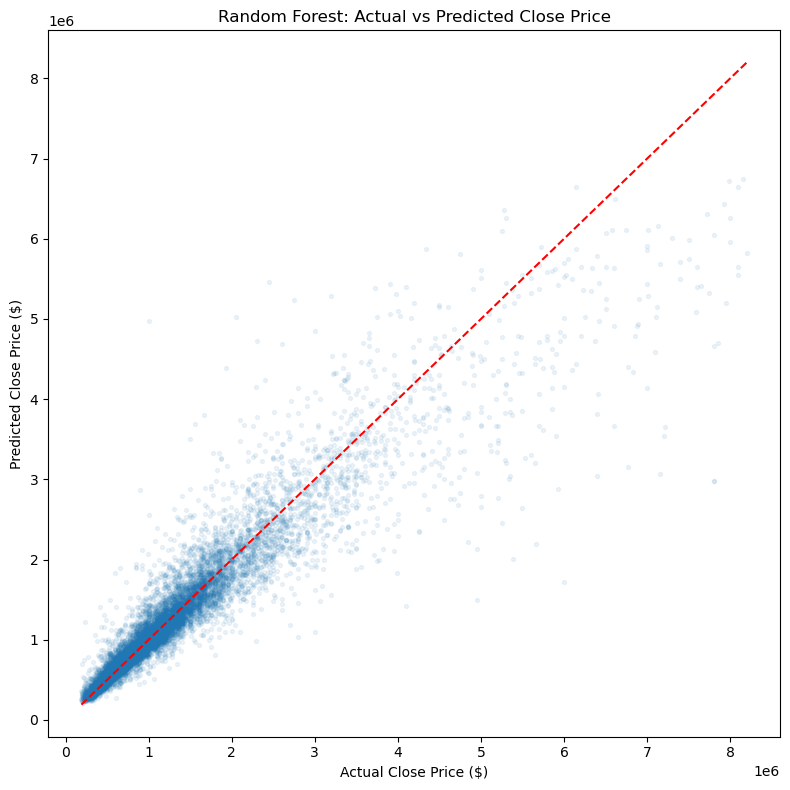

In [27]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_rf, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Random Forest: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## Previous Model Results

| Model                   |     R² |            MAE | MAPE (%) | MdAPE (%) |           RMSE |
| ----------------------- | -----: | -------------: | -------: | --------: | -------------: |
| Linear Regression       | 0.6405 | USD 368,707.93 | 33.8549% |  25.1820% | USD 586,081.35 |
| Decision Tree Regressor | 0.8130 | USD 208,460.26 | 15.1352% |   9.9675% | USD 422,718.61 |
| Random Forest Regressor | 0.8609 | USD 192,948.57 | 14.8471% |  10.1211% | USD 364,520.98 |

## Previous Evaluation Summary

The Decision Tree and Random Forest models substantially outperformed the Linear Regression baseline on the held-out testing dataset.

The Decision Tree Regressor increased the R² score from 0.6405 to 0.8130, indicating that nonlinear relationships between property characteristics and sale prices were successfully captured. Compared with the baseline, both MAE and RMSE decreased considerably, demonstrating a substantial improvement in prediction accuracy.

The Random Forest Regressor achieved the strongest overall performance, with an R² score of 0.8609, an MAE of USD 192,948.57, and an RMSE of USD 364,520.98. By aggregating predictions from multiple decision trees, the Random Forest produced more stable predictions and reduced large prediction errors compared with a single Decision Tree.

Although the Decision Tree achieved a slightly lower MdAPE than the Random Forest, the Random Forest produced the strongest overall performance based on R², MAE, and RMSE, making it the strongest candidate for subsequent feature engineering and advanced model development.

## Current Model Results

| Model | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---:|---:|---:|---:|---:|
| Linear Regression | 0.6410 | USD 358,844.63 | 33.0237% | 24.9839% | USD 588,238.00 |
| Decision Tree Regressor | 0.8131 | USD 210,221.47 | 15.5580% | 10.1449% | USD 424,456.10 |
| Random Forest Regressor | **0.8749** | **USD 168,931.31** | **12.4763%** | **7.9706%** | **USD 347,200.70** |

## Current Evaluation Summary

The current results were generated using the chronological train/validation/test workflow. Decision Tree and Random Forest configurations were selected using the validation month, after which each final model was refitted on the combined training and validation data and evaluated once on the held-out testing month.

The Linear Regression model established an R² baseline of 0.6410, with an MAE of USD 358,844.63 and an MdAPE of 24.9839%. Its MAPE remained substantially higher than its MdAPE, and its RMSE remained higher than its MAE, indicating that a minority of difficult properties continued to produce relatively large percentage and dollar errors.

The Decision Tree Regressor substantially outperformed Linear Regression, achieving an R² of 0.8131 and reducing MdAPE to 10.1449%. Compared with the previous Decision Tree result, its current performance was broadly stable: R² increased by only 0.0001, while MAE, MAPE, MdAPE, and RMSE were slightly worse. This suggests that the single-tree model has reached a similar performance range under the revised validation workflow.

The Random Forest Regressor achieved the strongest result across every reported metric: R² increased to 0.8749, MAE decreased to USD 168,931.31, MAPE decreased to 12.4763%, MdAPE decreased to 7.9706%, and RMSE decreased to USD 347,200.70. Relative to the previous Random Forest result, R² improved by 0.0140, MAE decreased by approximately USD 24,017, MAPE decreased by 2.3708 percentage points, MdAPE decreased by 2.1505 percentage points, and RMSE decreased by approximately USD 17,320.

Compared with the current Linear Regression baseline, Random Forest reduced MAE by approximately USD 189,913 and MdAPE by 17.0133 percentage points while explaining substantially more variation in sale prices. The improvement across both mean- and median-based error metrics indicates that the gain was not limited to only a small subset of observations.

Among the three tested models, Random Forest is therefore the strongest current candidate. Its advantage over the single Decision Tree also demonstrates the benefit of aggregating multiple trees to capture nonlinear relationships while reducing the instability and large errors associated with an individual tree.

These held-out test results establish the updated benchmark for the next stages of feature-set comparison, rolling-origin evaluation, and advanced gradient-boosting models.

## Old vs. New Feature Set Comparison

This comparison reconstructs the old encoded feature set from the pre-Week 6 preprocessing output and compares it with the current encoded training schema. The counts below refer to model predictors after encoding and exclude the target variable, `ClosePrice`.

| Feature-set measure | Old feature set | New feature set |
|---|---:|---:|
| Encoded predictors | 106 | 127 |
| Predictors retained from the old set | 106 | 106 |
| Newly added predictors | 0 | 21 |
| Predictors removed from the old set | 0 | 0 |

The new feature set is therefore a strict superset of the old feature set: all 106 original predictors were retained and 21 encoded predictors were added.

### Added Feature Groups

| Feature group | Added encoded predictors | Purpose |
|---|---:|---|
| Property age | 5 | Represent continuous property age and nonlinear age ranges |
| Housing and space ratios | 6 | Capture layout, space utilization, and parking capacity relative to property size |
| Amenity summary and interactions | 7 | Represent amenity richness and selected combinations of property characteristics |
| School-district system type | 3 | Add lower-dimensional geographic context without using individual district identity |
| **Total** | **21** | |

**Property-age features:** `PropertyAge`, `AgeBucket_New`, `AgeBucket_Modern`, `AgeBucket_Mature`, and `AgeBucket_Historic`.

**Housing and space-ratio features:** `BathroomsPerBedroom`, `LivingAreaPerBedroom`, `LivingAreaPerBathroom`, `LivingAreaLotRatio`, `LotSizePerBedroom`, and `GarageSpacesPerBedroom`.

**Amenity summary and interaction features:** `AmenityCount`, `PoolAndWaterfront`, `WaterfrontAndView`, `PoolAndGarage`, `FireplaceAndBasement`, `NewConstructionAndGarage`, and `PremiumAmenityCombo`.

**School-district system-type features:** `DistrictType_Elementary`, `DistrictType_High`, and `DistrictType_Unified`.

### Interpretation Limitation

This is a descriptive schema comparison, not a controlled performance comparison. The previous and current model results were produced under different preprocessing, validation, tuning, and feature-engineering workflows, so their metric differences cannot be attributed solely to the 21 added predictors.

A controlled feature-set experiment should hold the chronological split, preprocessing rules, model type, hyperparameters, and random seed constant; compare the 106-predictor and 127-predictor sets on the validation month; select the feature set using validation results only; and then refit the selected configuration on training plus validation data for one final test-month evaluation.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship